In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


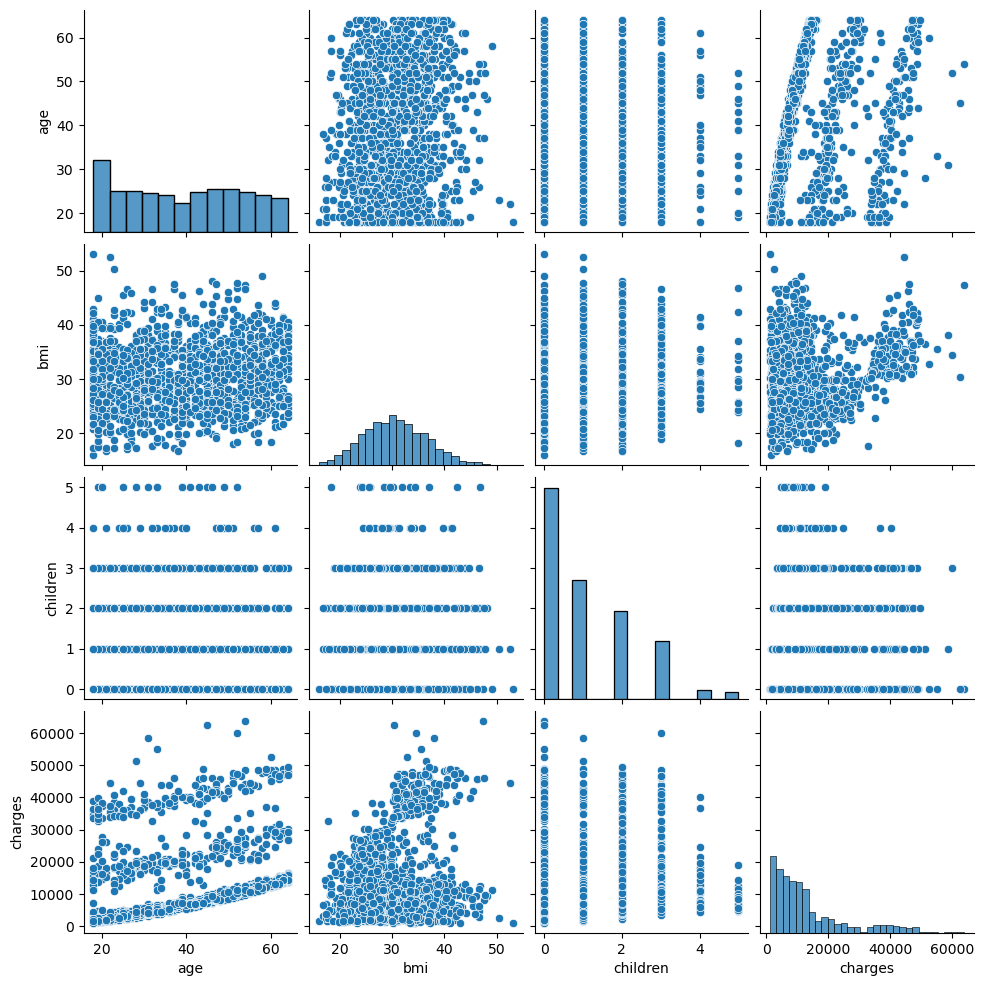

In [2]:
insurance_data=pd.read_csv("insurance.csv")
X=insurance_data.drop(columns=["charges","region"])
y=insurance_data["charges"]
X["sex"]=X["sex"].map({"female":1,"male":0})
X["smoker"]=X["smoker"].map({"yes":1,"no":0})



In [3]:
X.head()

,age,sex,bmi,children,smoker
0,19,1,27.900,0,1
1,18,0,33.770,1,0
2,28,0,33.000,3,0
3,33,0,22.705,0,0
4,32,0,28.880,0,0


In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [5]:
#train model
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [6]:
y_pred=model.predict(X_test)
y_pred

array([ 8554.81711589,  6973.58746745, 36798.60416104,  9417.88282303,
       26871.68031081, 11097.38383938,   145.27608963, 16746.1683771 ,
         747.53414191, 11153.67590722, 28518.15016561,  9292.18345421,
        5460.51975119, 38510.48013003, 40359.30938604, 37223.40538064,
       15316.56711945, 36047.50032223,  9326.29049907, 31400.1559532 ,
        4269.64414373, 10464.66374097,  2719.9260555 ,  6579.53742551,
       11232.00255515, 12472.06793446, 14807.11281089,  6066.19283362,
        9535.69029723,  2377.6983797 ,  9475.05690885, 12963.23366722,
        4706.09057393,  3414.674504  ,  4815.64981654, 12484.17176954,
        2359.13614479,  9161.02061228, 33238.67621442, 32743.41702445,
        4274.58967205,  4229.5442107 , 14435.36485176, 11384.66898976,
        8925.70468583, 12480.09178788,  5154.45787816,  3554.10047649,
       35649.60942684,  9276.25523701, 15971.35991397,  2552.75200479,
       12162.99980138,  1062.65132285, 13551.43771934, 12103.65505529,
      

In [7]:
#evalute
from sklearn.metrics import r2_score
r2=r2_score(y_test, y_pred)
n=X_test.shape[0]
p=X_test.shape[1]

adjusted_r2=1-((1-r2)*(n-1)/(n-p-1))

print("r2 value: ",r2)



r2 value:  0.7811302113434095
adjusted r-squared :  0.7769533069797342


In [9]:
#interaction features
X=insurance_data.drop(columns=["charges"])
y=insurance_data["charges"]

X=pd.get_dummies(X,columns=["region"],drop_first=True,dtype=int)
X["sex"]=X["sex"].map({"female":1,"male":0})
X["smoker"]=X["smoker"].map({"yes":1,"no":0})

X["age_smoker"]=X["age"]*X["smoker"]
X["bmi_smoker"]=X["bmi"]*X["smoker"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model=LinearRegression()
model.fit(X_train,y_train)

y_pred=model.predict(X_test)

r2=r2_score(y_test,y_pred)
print(r2)

0.865231697953168


In [11]:
y_train_pred=model.predict(X_train)
r2_train=r2_score(y_train_pred,y_train)

print("training data : ",r2_train)
print("testing data : ",r2)

training data :  0.8010618340071711
testing data :  0.865231697953168
